In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.2


In [2]:
data_path = "../data"

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

print("Dataset path:", data_path)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)

Dataset path: ../data
Image size: (128, 128)
Batch size: 32


In [3]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

print("Training dataset loaded!")

Found 2527 files belonging to 6 classes.
Using 1769 files for training.
Training dataset loaded!


In [4]:
validation_test_dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

print("Validation/Test dataset loaded!")

Found 2527 files belonging to 6 classes.
Using 758 files for validation.
Validation/Test dataset loaded!


In [5]:
total_batches = tf.data.experimental.cardinality(
    validation_test_dataset
).numpy()

test_batches = total_batches // 2

test_dataset = validation_test_dataset.take(test_batches)
validation_dataset = validation_test_dataset.skip(test_batches)

print("Validation and test datasets created!")

Validation and test datasets created!


In [6]:
class_names = train_dataset.class_names

print("Classes:")

for index, class_name in enumerate(class_names):
    print(index, "->", class_name)

Classes:
0 -> cardboard
1 -> glass
2 -> metal
3 -> paper
4 -> plastic
5 -> trash


In [7]:
model = tf.keras.Sequential([
    
    tf.keras.layers.Input(shape=(128, 128, 3)),
    
    # Normalize pixel values from 0-255 to 0-1
    tf.keras.layers.Rescaling(1./255),
    
    # First convolution block
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),
    
    # Second convolution block
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),
    
    # Third convolution block
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),
    
    # Convert feature maps into one vector
    tf.keras.layers.Flatten(),
    
    # Fully connected layer
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),
    
    # Reduce overfitting
    tf.keras.layers.Dropout(0.5),
    
    # Six waste classes
    tf.keras.layers.Dense(
        6,
        activation="softmax"
    )
])

print("CNN model created successfully!")

CNN model created successfully!


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [10]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15
)

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.3188 - loss: 1.6365 - val_accuracy: 0.4091 - val_loss: 1.4139
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - accuracy: 0.4194 - loss: 1.4463 - val_accuracy: 0.4198 - val_loss: 1.3927
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - accuracy: 0.4856 - loss: 1.3082 - val_accuracy: 0.4626 - val_loss: 1.3462
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - accuracy: 0.5331 - loss: 1.2145 - val_accuracy: 0.5508 - val_loss: 1.1962
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - accuracy: 0.5721 - loss: 1.1105 - val_accuracy: 0.5160 - val_loss: 1.1739
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - accuracy: 0.5947 - loss: 1.0775 - val_accuracy: 0.5615 - val_loss: 1.1242
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - accuracy: 0.6388 - loss: 0.9750 - val_accuracy: 0.6176 - val_loss: 1.0051
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.6490 - loss: 0.9068 - val_accuracy: 

In [11]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15
)

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step - accuracy: 0.8485 - loss: 0.4245 - val_accuracy: 0.6257 - val_loss: 1.2125
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step - accuracy: 0.8756 - loss: 0.3797 - val_accuracy: 0.6257 - val_loss: 1.2443
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - accuracy: 0.8632 - loss: 0.3752 - val_accuracy: 0.6390 - val_loss: 1.3378
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - accuracy: 0.8711 - loss: 0.3595 - val_accuracy: 0.6283 - val_loss: 1.6076
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step - accuracy: 0.8864 - loss: 0.3240 - val_accuracy: 0.6497 - val_loss: 1.3136
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - accuracy: 0.9011 - loss: 0.2701 - val_accuracy: 0.6070 - val_loss: 1.6168
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.8949 - loss: 0.3046 - val_accuracy: 0.6658 - val_loss: 1.4131
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - accuracy: 0.9175 - loss: 0.2332 - val_accuracy: 0

The initial CNN achieved high training accuracy but substantially lower validation accuracy, indicating overfitting. I addressed this using image augmentation, class weighting, batch normalization, and early stopping."

In [12]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Baseline CNN Test Results")
print("-------------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6484 - loss: 1.9103
Baseline CNN Test Results
-------------------------
Test Loss: 1.9103
Test Accuracy: 0.6484
Test Accuracy: 64.84%


Baseline CNN Classification Report
-----------------------------------
              precision    recall  f1-score   support

   cardboard       0.86      0.82      0.84        60
       glass       0.55      0.60      0.57        87
       metal       0.50      0.44      0.47        55
       paper       0.66      0.80      0.72        89
     plastic       0.65      0.60      0.62        73
       trash       0.56      0.25      0.34        20

    accuracy                           0.64       384
   macro avg       0.63      0.58      0.59       384
weighted avg       0.64      0.64      0.63       384



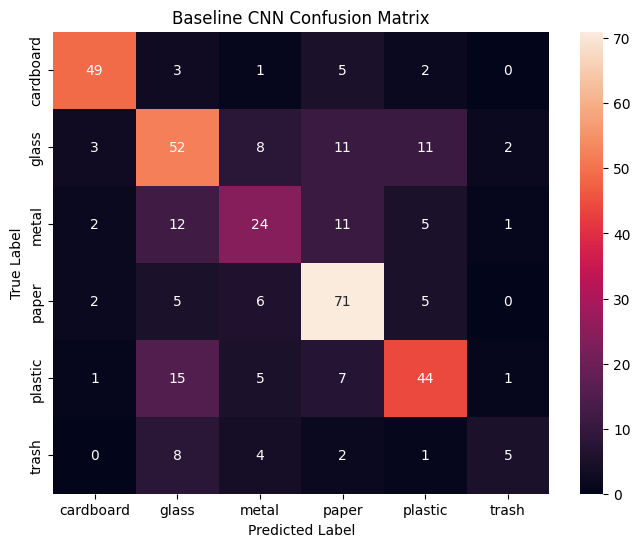

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Class names
class_names = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

# Classification Report
print("Baseline CNN Classification Report")
print("-----------------------------------")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Baseline CNN Confusion Matrix")
plt.show()

In [14]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

print("Data augmentation created successfully!")

Data augmentation created successfully!


In [17]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

DATA_DIR = "../data"

CLASS_NAMES = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

image_paths = []
labels = []

for label, class_name in enumerate(CLASS_NAMES):

    class_path = os.path.join(DATA_DIR, class_name)

    for file in os.listdir(class_path):

        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            image_paths.append(
                os.path.join(class_path, file)
            )

            labels.append(label)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total images:", len(image_paths))

Total images: 2527


In [18]:
X_temp, X_test, y_temp, y_test = train_test_split(
    image_paths,
    labels,
    test_size=0.15,
    random_state=42,
    stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    random_state=42,
    stratify=y_temp
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Testing images:", len(X_test))

Training images: 1768
Validation images: 379
Testing images: 380


In [19]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    i: weight
    for i, weight in enumerate(class_weights_array)
}

print("Class Weights")
print("-------------")

for i, class_name in enumerate(CLASS_NAMES):
    print(f"{class_name}: {class_weights[i]:.4f}")

Class Weights
-------------
cardboard: 1.0449
glass: 0.8395
metal: 1.0303
paper: 0.7083
plastic: 0.8718
trash: 3.1018


In [20]:
cnn_v2 = tf.keras.Sequential([
    
    # Input
    tf.keras.layers.Input(
        shape=(128, 128, 3)
    ),

    # Data Augmentation
    data_augmentation,

    # Normalize pixel values
    tf.keras.layers.Rescaling(1./255),

    # Convolution Block 1
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolution Block 4
    tf.keras.layers.Conv2D(
        256,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Global Average Pooling
    tf.keras.layers.GlobalAveragePooling2D(),

    # Dense layer
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Dropout
    tf.keras.layers.Dropout(0.5),

    # Output
    tf.keras.layers.Dense(
        6,
        activation="softmax"
    )
])

print("CNN Version 2 created successfully!")

CNN Version 2 created successfully!


In [21]:
cnn_v2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,006 (1.62 MB)

 Trainable params: 423,046 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [22]:
cnn_v2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN Version 2 compiled successfully!")

CNN Version 2 compiled successfully!


In [23]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "../models/waste_cnn_v2.keras",
    monitor="val_accuracy",
    save_best_only=True
)

print("Callbacks created successfully!")

Callbacks created successfully!


In [24]:
history_v2 = cnn_v2.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        reduce_lr,
        model_checkpoint
    ]
)

Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 345ms/step - accuracy: 0.4217 - loss: 1.5337 - val_accuracy: 0.2166 - val_loss: 1.9200 - learning_rate: 0.0010
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 391ms/step - accuracy: 0.4845 - loss: 1.3286 - val_accuracy: 0.2032 - val_loss: 1.9988 - learning_rate: 0.0010
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 424ms/step - accuracy: 0.5353 - loss: 1.2453 - val_accuracy: 0.1791 - val_loss: 2.0335 - learning_rate: 0.0010
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 474ms/step - accuracy: 0.5676 - loss: 1.1330 - val_accuracy: 0.2299 - val_loss: 2.1211 - learning_rate: 5.0000e-04
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 469ms/step - accuracy: 0.5998 - loss: 1.0640 - val_accuracy: 0.1952 - val_loss: 1.8897 - learning_rate: 5.0000e-04
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 506ms/step - accuracy: 0.6269 - loss: 0.9865 - val_accuracy: 0.2781 - val_loss: 1.7530 - learning_rate: 5.0000e-04
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 492ms/step - accuracy: 0.634

In [25]:
test_loss_v2, test_accuracy_v2 = cnn_v2.evaluate(
    test_dataset,
    verbose=1
)

print("\nCNN Version 2 Test Results")
print("--------------------------")
print(f"Test Loss: {test_loss_v2:.4f}")
print(f"Test Accuracy: {test_accuracy_v2:.4f}")
print(f"Test Accuracy: {test_accuracy_v2 * 100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.7760 - loss: 0.6550

CNN Version 2 Test Results
--------------------------
Test Loss: 0.6550
Test Accuracy: 0.7760
Test Accuracy: 77.60%


In [26]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = cnn_v2.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print("CNN Version 2 Classification Report")
print("------------------------------------")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )
)

CNN Version 2 Classification Report
------------------------------------
              precision    recall  f1-score   support

   cardboard     0.9206    0.9206    0.9206        63
       glass     0.8939    0.7108    0.7919        83
       metal     0.6479    0.7797    0.7077        59
       paper     0.8795    0.8588    0.8690        85
     plastic     0.8182    0.6750    0.7397        80
       trash     0.3429    0.8571    0.4898        14

    accuracy                         0.7865       384
   macro avg     0.7505    0.8004    0.7531       384
weighted avg     0.8214    0.7865    0.7953       384



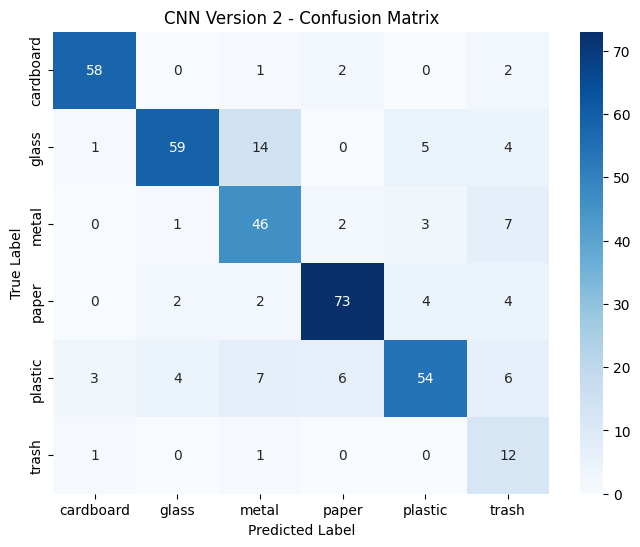

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_v2 = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_v2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Version 2 - Confusion Matrix")
plt.show()

In [28]:
print("Test dataset batches:", tf.data.experimental.cardinality(test_dataset).numpy())

total_test_images = 0

for images, labels in test_dataset:
    total_test_images += images.shape[0]

print("Total test images:", total_test_images)

Test dataset batches: 12
Total test images: 384


In [29]:
# Re-evaluate the exact same test dataset
test_loss_check, test_accuracy_check = cnn_v2.evaluate(
    test_dataset,
    verbose=0
)

# Generate predictions from the same test dataset
y_true_check = []
y_pred_check = []

for images, labels in test_dataset:
    predictions = cnn_v2.predict(images, verbose=0)

    y_true_check.extend(labels.numpy())
    y_pred_check.extend(np.argmax(predictions, axis=1))

# Calculate accuracy manually
manual_accuracy = np.mean(
    np.array(y_true_check) == np.array(y_pred_check)
)

print("Test Images:", len(y_true_check))
print(f"Keras Evaluate Accuracy: {test_accuracy_check * 100:.2f}%")
print(f"Manual Accuracy: {manual_accuracy * 100:.2f}%")

print("\nCorrect Predictions:",
      np.sum(np.array(y_true_check) == np.array(y_pred_check)))

print("Incorrect Predictions:",
      np.sum(np.array(y_true_check) != np.array(y_pred_check)))

Test Images: 384
Keras Evaluate Accuracy: 78.12%
Manual Accuracy: 77.08%

Correct Predictions: 296
Incorrect Predictions: 88


In [30]:
AUTOTUNE = tf.data.AUTOTUNE
IMAGE_SIZE = (128, 128)

def load_test_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label


clean_test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

clean_test_dataset = clean_test_dataset.map(
    load_test_image,
    num_parallel_calls=AUTOTUNE
).batch(
    32
).prefetch(AUTOTUNE)

print("Clean test dataset created successfully!")
print(
    "Test images:",
    len(X_test)
)

Clean test dataset created successfully!
Test images: 380


In [31]:
clean_test_loss, clean_test_accuracy = cnn_v2.evaluate(
    clean_test_dataset,
    verbose=1
)

print("\nCNN Version 2 Final Test Results")
print("--------------------------------")
print(f"Test Loss: {clean_test_loss:.4f}")
print(f"Test Accuracy: {clean_test_accuracy:.4f}")
print(f"Test Accuracy: {clean_test_accuracy * 100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.8316 - loss: 0.5022

CNN Version 2 Final Test Results
--------------------------------
Test Loss: 0.5022
Test Accuracy: 0.8316
Test Accuracy: 83.16%


In [32]:
best_model = tf.keras.models.load_model(
    "../models/waste_cnn_v2.keras"
)

best_test_loss, best_test_accuracy = best_model.evaluate(
    clean_test_dataset,
    verbose=1
)

print("\nBest CNN Version 2 Test Results")
print("--------------------------------")
print(f"Test Loss: {best_test_loss:.4f}")
print(f"Test Accuracy: {best_test_accuracy:.4f}")
print(f"Test Accuracy: {best_test_accuracy * 100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.8026 - loss: 0.5705

Best CNN Version 2 Test Results
--------------------------------
Test Loss: 0.5705
Test Accuracy: 0.8026
Test Accuracy: 80.26%


In [33]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in clean_test_dataset:
    predictions = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print("Final CNN Version 2 Classification Report")
print("------------------------------------------")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )
)

Final CNN Version 2 Classification Report
------------------------------------------
              precision    recall  f1-score   support

   cardboard     0.9333    0.9180    0.9256        61
       glass     0.8966    0.6933    0.7820        75
       metal     0.6712    0.7903    0.7259        62
       paper     0.8916    0.8315    0.8605        89
     plastic     0.7714    0.7500    0.7606        72
       trash     0.5556    0.9524    0.7018        21

    accuracy                         0.8026       380
   macro avg     0.7866    0.8226    0.7927       380
weighted avg     0.8220    0.8026    0.8058       380



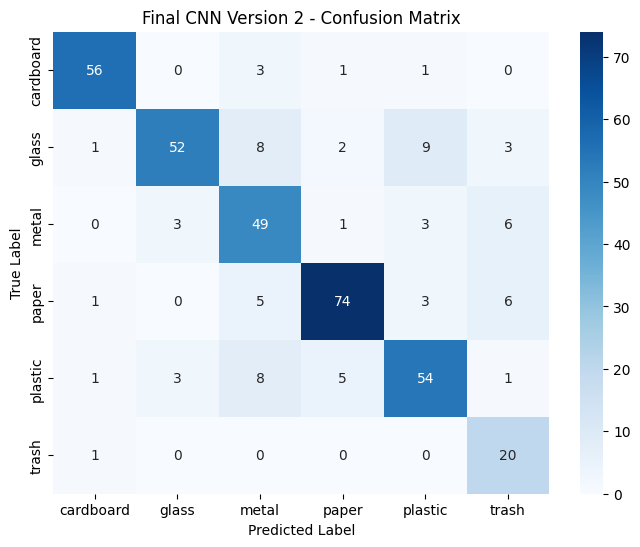

In [34]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_final = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final CNN Version 2 - Confusion Matrix")
plt.show()

In [35]:
best_model.save("../models/waste_cnn_final.keras")

print("Final model saved successfully!")

Final model saved successfully!
